# Level 3: Advanced Machine Learning
## Task 1: Build a Random Forest Classifier
**Dataset:** Customer Churn Prediction Dataset

### 1. Load and Preprocess the Dataset
Loading the dataset and encoding the categorical features. Note that Random Forest models do not require feature scaling (like StandardScaler), as they partition data based on thresholds rather than distance calculations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Load the dataset (adjust the path if it is inside the folder)
df = pd.read_csv(r'D:\AI\Ai_intern\Data Set For Task\Churn Prdiction Data\churn-bigml-80.csv')

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y_raw = df['Churn']

# Encode categorical variables using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Encode the target variable (False -> 0, True -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print(f"Encoded features shape: {X_encoded.shape}")

Encoded features shape: (2666, 68)


### 2. Hyperparameter Tuning and Cross-Validation
We will use `GridSearchCV` to test different combinations of hyperparameters (`n_estimators` and `max_depth`). This process uses 5-fold cross-validation to ensure the model's robustness and selects the parameters that yield the highest F1-score.

In [2]:
# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None]
}

# Initialize the base Random Forest model
rf_base = RandomForestClassifier(random_state=42)

# Perform Grid Search with 5-fold Cross-Validation, optimizing for F1-score
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extract the best model
best_rf = grid_search.best_estimator_

print(f"Optimal Hyperparameters Found: {grid_search.best_params_}")

# Perform explicit cross-validation on the training set using the best model
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='f1')
print(f"\nCross-Validation F1-Scores across 5 folds: {cv_scores}")
print(f"Mean Cross-Validation F1-Score: {cv_scores.mean():.4f}")

Optimal Hyperparameters Found: {'max_depth': 20, 'n_estimators': 200}

Cross-Validation F1-Scores across 5 folds: [0.72164948 0.66666667 0.77227723 0.78431373 0.75      ]
Mean Cross-Validation F1-Score: 0.7390


### 3. Evaluate the Model (Precision, Recall, F1-Score)
Testing the optimized Random Forest model on the unseen test dataset and evaluating its performance using classification metrics.

In [3]:
# Make predictions on the test set
y_pred = best_rf.predict(X_test)

# Calculate individual metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Set Precision: {precision:.4f}")
print(f"Test Set Recall:    {recall:.4f}")
print(f"Test Set F1-Score:  {f1:.4f}\n")

# Display the full classification report
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

Test Set Precision: 1.0000
Test Set Recall:    0.4937
Test Set F1-Score:  0.6610

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       455
           1       1.00      0.49      0.66        79

    accuracy                           0.93       534
   macro avg       0.96      0.75      0.81       534
weighted avg       0.93      0.93      0.91       534



### 4. Feature Importance Analysis
Random Forest models inherently calculate feature importance. We will extract these values and visualize the top features that contribute most to predicting customer churn.

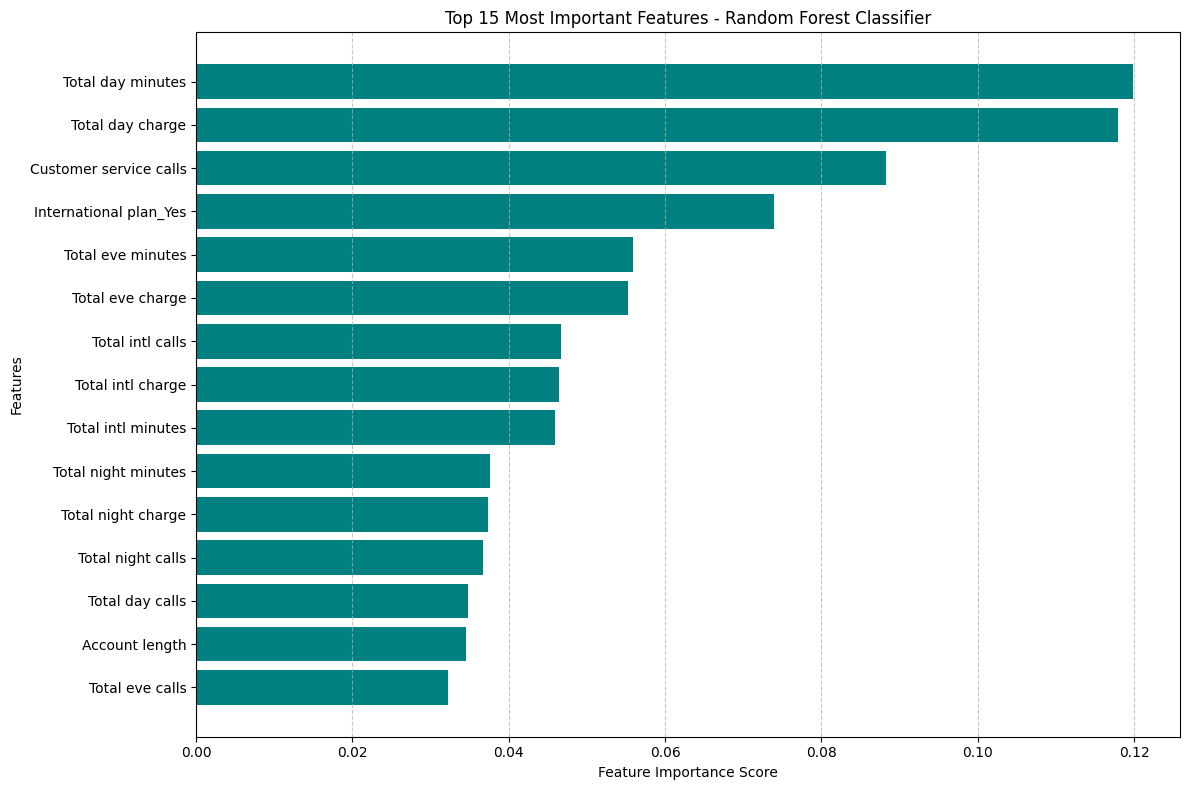

In [4]:
# Extract feature importances from the optimized model
importances = best_rf.feature_importances_

# Create a DataFrame for better handling
feature_importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importances
})

# Sort the features by importance score in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 15 most important features
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'][:15][::-1], feature_importance_df['Importance'][:15][::-1], color='teal')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Top 15 Most Important Features - Random Forest Classifier')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()